1. 非线性激活函数的重要性
隐藏层无激活函数时：

h
=
W
1
x
+
b
1
,
o
=
W
2
h
+
b
2
h=W 
1
​
 x+b 
1
​
 ,o=W 
2
​
 h+b 
2
​
 
代入得：

o
=
W
2
(
W
1
x
+
b
1
)
+
b
2
=
(
W
2
W
1
)
x
+
(
W
2
b
1
+
b
2
)
o=W 
2
​
 (W 
1
​
 x+b 
1
​
 )+b 
2
​
 =(W 
2
​
 W 
1
​
 )x+(W 
2
​
 b 
1
​
 +b 
2
​
 )
令 
W
′
=
W
2
W
1
W 
′
 =W 
2
​
 W 
1
​
 ，
b
′
=
W
2
b
1
+
b
2
b 
′
 =W 
2
​
 b 
1
​
 +b 
2
​
 ，则有 
o
=
W
′
x
+
b
′
o=W 
′
 x+b 
′
 ，等价于单层线性网络。因此没有非线性激活函数，多层网络只能表示线性变换，无法拟合复杂函数。

2. 激活函数性质分析

σ
(
x
)
=
1
1
+
e
−
x
,
σ
′
(
x
)
=
σ
(
x
)
(
1
−
σ
(
x
)
)
σ(x)= 
1+e 
−x
 
1
​
 ,σ 
′
 (x)=σ(x)(1−σ(x))
tanh
⁡
(
x
)
=
e
x
−
e
−
x
e
x
+
e
−
x
,
tanh
⁡
′
(
x
)
=
1
−
tanh
⁡
2
(
x
)
tanh(x)= 
e 
x
 +e 
−x
 
e 
x
 −e 
−x
 
​
 ,tanh 
′
 (x)=1−tanh 
2
 (x)

In [17]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import urllib.request
import gzip
import os
import sys

torch.manual_seed(42)

# ========== 工具函数 ==========
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def softmax_cross_entropy(logits, y):
    exps = torch.exp(logits - torch.max(logits, dim=1, keepdim=True).values)
    probs = exps / exps.sum(dim=1, keepdim=True)
    return -torch.log(probs[range(y.shape[0]), y] + 1e-9).mean()

# ========== 带进度条的下载 ==========
def download_with_progress(url, path):
    print(f"下载 {os.path.basename(path)} ...")
    def reporthook(block_num, block_size, total_size):
        downloaded = block_num * block_size
        if total_size > 0:
            percent = min(100, downloaded * 100.0 / total_size)
            bar_len = 30
            filled = int(bar_len * percent / 100)
            bar = '█' * filled + '-' * (bar_len - filled)
            sys.stdout.write(f'\r|{bar}| {percent:.1f}%  {downloaded/1024/1024:.1f}/{total_size/1024/1024:.1f} MB')
            sys.stdout.flush()
    urllib.request.urlretrieve(url, path, reporthook)
    print()

# ========== Fashion-MNIST 下载与解析 ==========
def load_fashion_mnist(data_dir='./data'):
    os.makedirs(data_dir, exist_ok=True)
    base_url = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
    files = {
        "train_images": "train-images-idx3-ubyte.gz",
        "train_labels": "train-labels-idx1-ubyte.gz",
        "test_images": "t10k-images-idx3-ubyte.gz",
        "test_labels": "t10k-labels-idx1-ubyte.gz"
    }
    expected_sizes = {
        "train_images": 9912422,
        "train_labels": 28881,
        "test_images": 1648877,
        "test_labels": 5142
    }

    data = {}
    for name, fname in files.items():
        path = os.path.join(data_dir, fname)
        expected = expected_sizes[name]

        if os.path.exists(path) and os.path.getsize(path) != expected:
            print(f"[警告] {fname} 大小异常，重新下载...")
            os.remove(path)

        if not os.path.exists(path):
            download_with_progress(base_url + fname, path)

        with gzip.open(path, 'rb') as f:
            if "images" in name:
                data[name] = np.frombuffer(f.read(), dtype=np.uint8, offset=16).reshape(-1, 28*28)
            else:
                data[name] = np.frombuffer(f.read(), dtype=np.uint8, offset=8)

    return (data["train_images"], data["train_labels"]), \
           (data["test_images"], data["test_labels"])

# ========== 加载数据 ==========
(X_train_np, y_train_np), (X_test_np, y_test_np) = load_fashion_mnist()

X_train = torch.tensor(X_train_np, dtype=torch.float32) / 255.0 * 2 - 1
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test  = torch.tensor(X_test_np, dtype=torch.float32) / 255.0 * 2 - 1
y_test  = torch.tensor(y_test_np, dtype=torch.long)

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

input_dim = 28*28
hidden_dim = 256
output_dim = 10

# ========== 参数初始化 ==========
W1 = torch.randn(input_dim, hidden_dim) * 0.01
b1 = torch.zeros(hidden_dim)
W2 = torch.randn(hidden_dim, output_dim) * 0.01
b2 = torch.zeros(output_dim)
params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

# ========== 训练 ==========
lr = 0.1
epochs = 10
for epoch in range(epochs):
    for X_batch, y_batch in train_loader:
        h = relu(X_batch @ W1 + b1)
        logits = h @ W2 + b2
        loss = softmax_cross_entropy(logits, y_batch)
        loss.backward()
        with torch.no_grad():
            for p in params:
                p -= lr * p.grad
                p.grad.zero_()

    with torch.no_grad():
        correct = 0
        for X_b, y_b in test_loader:
            logits = relu(X_b @ W1 + b1) @ W2 + b2
            correct += (torch.argmax(logits, dim=1) == y_b).sum().item()
        acc = correct / len(y_test)
        print(f"Epoch {epoch+1:2d}, Test Acc: {acc:.4f}")

[警告] train-images-idx3-ubyte.gz 大小异常，重新下载...
下载 train-images-idx3-ubyte.gz ...
|██████████████████████████████| 100.0%  25.2/25.2 MB
下载 train-labels-idx1-ubyte.gz ...
|██████████████████████████████| 100.0%  0.0/0.0 MB
下载 t10k-images-idx3-ubyte.gz ...
|██████████████████████████████| 100.0%  4.2/4.2 MB
下载 t10k-labels-idx1-ubyte.gz ...
|██████████████████████████████| 100.0%  0.0/0.0 MB
Epoch  1, Test Acc: 0.7721
Epoch  2, Test Acc: 0.8376
Epoch  3, Test Acc: 0.8397
Epoch  4, Test Acc: 0.8602
Epoch  5, Test Acc: 0.8625
Epoch  6, Test Acc: 0.8704
Epoch  7, Test Acc: 0.8673
Epoch  8, Test Acc: 0.8738
Epoch  9, Test Acc: 0.8642
Epoch 10, Test Acc: 0.8715


1. 过拟合与欠拟合
训练误差是模型在训练集上的平均损失；泛化误差是模型在独立同分布的测试数据上的期望损失。
训练误差极低而泛化误差很高时，模型处于过拟合状态——它过度记忆了训练数据的噪声和细节，丧失了通用性。
缓解方法：降低模型复杂度（减少神经元、层数）、增加训练数据、使用正则化（L2、Dropout）、早停等。

2. K 折交叉验证步骤

将数据集随机划分为 
K
K 个大小相近的互斥子集（折）。

对于 
i
=
1
,
…
,
K
i=1,…,K：
 • 以第 
i
i 折作为验证集，其余 
K
−
1
K−1 折作为训练集；
 • 训练模型并在验证集上计算评估指标。

将 
K
K 次评估结果的平均值作为模型性能的估计，常用于模型选择与超参数调优。

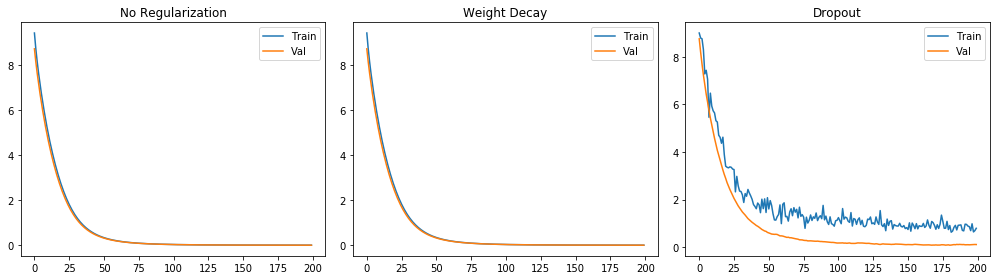

In [13]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ========== 工具函数 ==========
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def dropout_layer(X, dropout_prob, is_training=True):
    if not is_training or dropout_prob == 0:
        return X
    mask = (torch.rand_like(X) > dropout_prob).float()
    return mask * X / (1.0 - dropout_prob)

# ========== 生成过拟合数据（高维小样本） ==========
def make_poly_data(n_samples=80, n_features=50, noise=0.1):
    torch.manual_seed(0)
    X = torch.randn(n_samples, n_features)
    true_W = torch.randn(n_features, 1) * 0.5
    y = X @ true_W + 0.5 * (X[:, 0:1] ** 2) + noise * torch.randn(n_samples, 1)
    return X, y

X_train_poly, y_train_poly = make_poly_data(80)
X_val_poly,   y_val_poly   = make_poly_data(80)

# ========== 训练函数 ==========
def train_mlp_regression(X_train, y_train, X_val, y_val, lr=0.01, epochs=200,
                          weight_decay=0.0, dropout_prob=0.0, use_dropout=False):
    torch.manual_seed(42)
    input_dim = X_train.shape[1]
    hidden_dim = 200
    W1 = torch.randn(input_dim, hidden_dim) * 0.1; b1 = torch.zeros(hidden_dim)
    W2 = torch.randn(hidden_dim, 1) * 0.1;            b2 = torch.zeros(1)
    params = [W1, b1, W2, b2]
    for p in params:
        p.requires_grad = True

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        # 前向
        h = X_train @ W1 + b1
        h_act = relu(h)
        if use_dropout:
            h_act = dropout_layer(h_act, dropout_prob, is_training=True)
        pred = h_act @ W2 + b2
        loss = ((pred - y_train) ** 2).mean()
        loss.backward()

        with torch.no_grad():
            for p in params:
                p *= (1 - lr * weight_decay)   # L2 权重衰减
                p -= lr * p.grad
                p.grad.zero_()
        train_losses.append(loss.item())

        # 验证
        with torch.no_grad():
            h_v = X_val @ W1 + b1
            h_act_v = relu(h_v)
            if use_dropout:
                h_act_v = dropout_layer(h_act_v, dropout_prob, is_training=False)
            pred_v = h_act_v @ W2 + b2
            val_loss = ((pred_v - y_val) ** 2).mean()
            val_losses.append(val_loss.item())
    return train_losses, val_losses

# ========== 三种配置实验 ==========
tl1, vl1 = train_mlp_regression(X_train_poly, y_train_poly, X_val_poly, y_val_poly,
                                weight_decay=0.0, dropout_prob=0.0)
tl2, vl2 = train_mlp_regression(X_train_poly, y_train_poly, X_val_poly, y_val_poly,
                                weight_decay=0.01, dropout_prob=0.0)
tl3, vl3 = train_mlp_regression(X_train_poly, y_train_poly, X_val_poly, y_val_poly,
                                weight_decay=0.0, dropout_prob=0.5, use_dropout=True)

# ========== 绘制对比曲线 ==========
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(tl1, label='Train'); plt.plot(vl1, label='Val')
plt.title('No Regularization'); plt.legend()
plt.subplot(1,3,2)
plt.plot(tl2, label='Train'); plt.plot(vl2, label='Val')
plt.title('Weight Decay'); plt.legend()
plt.subplot(1,3,3)
plt.plot(tl3, label='Train'); plt.plot(vl3, label='Val')
plt.title('Dropout'); plt.legend()
plt.tight_layout()
plt.show()

1. 梯度消失与梯度爆炸
反向传播中，第 
t
t 层的梯度包含连乘项：

∏
i
=
t
d
−
1
∂
h
(
i
+
1
)
∂
h
(
i
)
=
∏
i
=
t
d
−
1
diag
⁡
(
σ
′
(
z
(
i
)
)
)
W
(
i
)
.
i=t
∏
d−1
​
  
∂h 
(i)
 
∂h 
(i+1)
 
​
 = 
i=t
∏
d−1
​
 diag(σ 
′
 (z 
(i)
 ))W 
(i)
 .
梯度爆炸：若权重矩阵 
W
(
i
)
W 
(i)
  的谱范数大于 1，且激活函数导数不衰减（如线性区），连乘导致梯度范数指数增长。

梯度消失：若权重谱范数小于 1，或激活函数导数远小于 1（如 Sigmoid 饱和区导数接近 0），连乘会使梯度指数衰减至零。

2. ReLU 为何缓解梯度消失
对于 
x
>
0
x>0，ReLU 的导数为 1，不会随深度增加而指数衰减。这使得梯度在正半轴可以稳定地反向传播，极大缓解了 Sigmoid/Tanh 在饱和区导致的梯度消失问题（但仍可能出现“死亡 ReLU”导致部分神经元永久失活）。



In [5]:
import torch.nn as nn

def build_net(activation, init_type, std=1.0):
    layers = []
    for _ in range(20):
        lin = nn.Linear(256, 256)
        if init_type == 'normal':
            nn.init.normal_(lin.weight, mean=0, std=std)
        elif init_type == 'xavier':
            nn.init.xavier_uniform_(lin.weight)
        layers.append(lin)
        layers.append(activation)
    return nn.Sequential(*layers)

x = torch.randn(1, 256)

# 1. Sigmoid + N(0,1) → 梯度消失
model1 = build_net(nn.Sigmoid(), 'normal', std=1.0)
model1(x).sum().backward()
for name, p in model1.named_parameters():
    if 'weight' in name:
        print(name, p.grad.norm().item())
# 前面几层梯度范数接近0，后面几层有值但很小

# 2. ReLU + N(0,10) → 梯度爆炸 / NaN
model2 = build_net(nn.ReLU(), 'normal', std=10.0)
model2(x).sum().backward()
print(any(torch.isnan(p.grad).any() for p in model2.parameters()))

# 3. Xavier + ReLU → 稳定
model3 = build_net(nn.ReLU(), 'xavier')
model3(x).sum().backward()
# 梯度范数稳定在合理区间

0.weight 799.7698974609375
2.weight 462.4493408203125
4.weight 386.18450927734375
6.weight 257.4150085449219


8.weight 251.34645080566406
10.weight 198.56349182128906
12.weight 165.51806640625
14.weight 125.15966033935547
16.weight 88.68241882324219
18.weight 53.82369613647461
20.weight 56.4430046081543
22.weight 61.96280288696289
24.weight 45.718894958496094
26.weight 33.7932243347168
28.weight 33.26387023925781
30.weight 22.80220603942871
32.weight 18.025344848632812
34.weight 15.066620826721191
36.weight 11.325201988220215
38.weight 13.680622100830078
True


协变量偏移与标签偏移

协变量偏移：
p
(
x
)
≠
q
(
x
)
p(x)

=q(x) 但 
p
(
y
∣
x
)
=
q
(
y
∣
x
)
p(y∣x)=q(y∣x)。
例：语音识别中，训练集是安静的录音，测试时带有街道噪声。输入特征分布变化，但相同文本的发音规律不变。

标签偏移：
p
(
y
)
≠
q
(
y
)
p(y)

=q(y) 但 
p
(
x
∣
y
)
=
q
(
x
∣
y
)
p(x∣y)=q(x∣y)。
例：医疗诊断中，训练数据里各类疾病样本均衡，但真实门诊时感冒远多于罕见病，导致标签分布变化，但给定疾病后的症状分布相同。

区别：协变量偏移源于 
x
x 的分布变化，标签偏移源于 
y
y 的分布变化。
联系：两者都属于训练与测试分布不一致，都可以用重要性加权（importance weighting）等方法进行校正。

Baseline MSE: 0.0402
Weighted MSE: 0.0446
Improvement: -0.0044


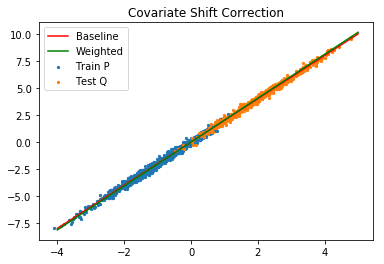

In [7]:
# 生成数据
torch.manual_seed(42)
n_train, n_test = 1000, 500
x_train = torch.randn(n_train, 1) - 1.0          # P: N(-1,1)
eps = 0.2 * torch.randn(n_train, 1)
y_train = 2 * x_train + eps

x_test = torch.randn(n_test, 1) + 2.0             # Q: N(2,1)
y_test = 2 * x_test + 0.2 * torch.randn(n_test, 1)

# ---------- 基线：最小二乘 ----------
X_train_aug = torch.cat([x_train, torch.ones(n_train, 1)], dim=1)
X_test_aug  = torch.cat([x_test,  torch.ones(n_test,  1)], dim=1)
w_base = torch.linalg.lstsq(X_train_aug, y_train).solution
mse_base = ((X_test_aug @ w_base - y_test) ** 2).mean().item()
print(f"Baseline MSE: {mse_base:.4f}")

# ---------- 域分类器 ----------
classifier = nn.Linear(1, 1)
opt = torch.optim.SGD(classifier.parameters(), lr=0.1)
X_all = torch.cat([x_train, x_test], dim=0)
y_label = torch.cat([torch.zeros(n_train, 1), torch.ones(n_test, 1)], dim=0)
for _ in range(200):
    loss = nn.BCEWithLogitsLoss()(classifier(X_all), y_label)
    opt.zero_grad(); loss.backward(); opt.step()

# 计算权重 w_i = P(test|x_i) / P(train|x_i)
with torch.no_grad():
    p_test_given_x = torch.sigmoid(classifier(x_train))
    weights = (p_test_given_x / (1 - p_test_given_x)).squeeze()

# ---------- 加权最小二乘 ----------
W = torch.diag(weights)
X = X_train_aug
w_weighted = torch.linalg.solve(X.T @ W @ X, X.T @ W @ y_train)
mse_weighted = ((X_test_aug @ w_weighted - y_test) ** 2).mean().item()
print(f"Weighted MSE: {mse_weighted:.4f}")
print(f"Improvement: {mse_base - mse_weighted:.4f}")

# 可视化
plt.figure()
plt.scatter(x_train.numpy(), y_train.numpy(), s=5, label='Train P')
plt.scatter(x_test.numpy(), y_test.numpy(), s=5, label='Test Q')
x_plot = torch.linspace(-4, 5, 200).unsqueeze(1)
X_plot = torch.cat([x_plot, torch.ones(200, 1)], dim=1)
plt.plot(x_plot, X_plot @ w_base, 'r', label='Baseline')
plt.plot(x_plot, X_plot @ w_weighted, 'g', label='Weighted')
plt.legend(); plt.title('Covariate Shift Correction')
plt.show()